Gerando Visualizações Regionais (PT)...


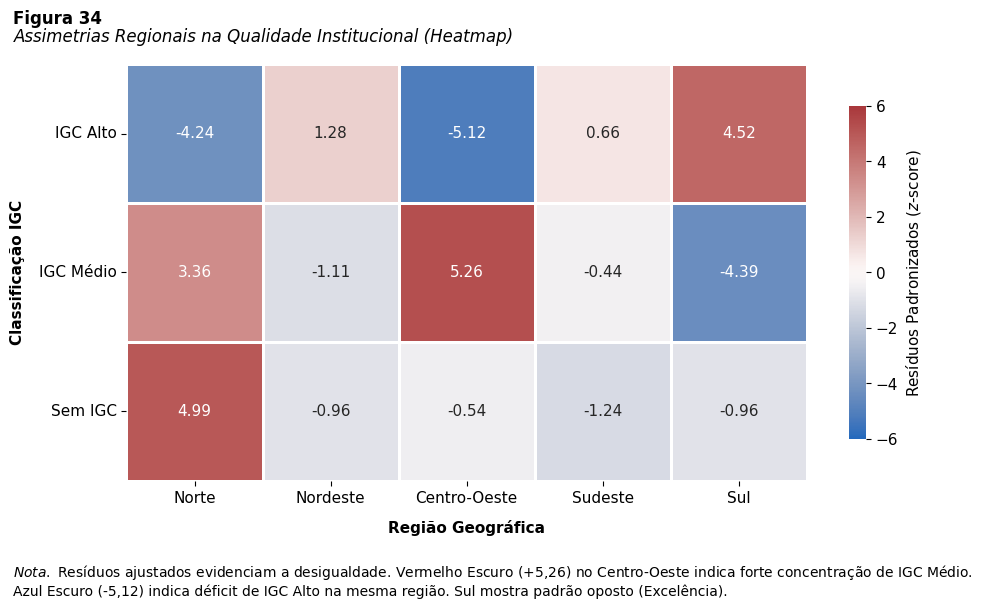

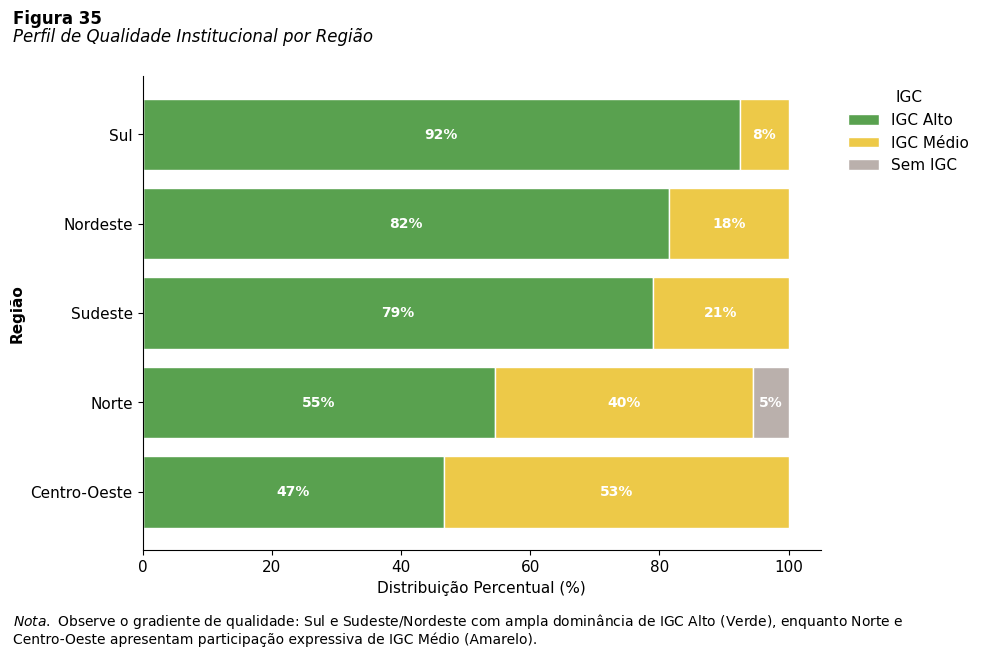

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.mosaicplot import mosaic
from matplotlib import rcParams
from matplotlib.lines import Line2D

# Configuração
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# Dados
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_regiao = 'regiao_corrigida'
col_igc = 'igc_categoria'

# Filtros (Apenas IES, conforme relatório)
if 'tem_igc' in df.columns:
    df = df[df['tem_igc'] == 1].copy()
else:
    df = df.dropna(subset=[col_igc])
df = df.dropna(subset=[col_regiao])

# Função Resíduos Ajustados (Haberman) - Bate com "Standardized" do SPSS/Jamovi
def get_adj_residuals(data, col_x, col_y):
    ct = pd.crosstab(data[col_y], data[col_x])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)
    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        adj_res = (observed - expected) / div
    return pd.DataFrame(adj_res, index=ct.index, columns=ct.columns).fillna(0)

# ==============================================================================
# 1. HEATMAP DE RESÍDUOS (GEOGRAFIA DA QUALIDADE)
# ==============================================================================
def plot_heatmap_regional_pt():
    residuos = get_adj_residuals(df, col_regiao, col_igc)

    # Ordenação IGC e Região (Norte -> Sul para lógica geográfica)
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ordem_reg = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

    residuos = residuos.reindex(index=ordem_igc, columns=ordem_reg)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(residuos, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-6, vmax=6,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Resíduos Padronizados ($z$-score)', 'shrink': 0.8}, ax=ax)

    ax.set_xlabel("Região Geográfica", weight='bold', labelpad=10)
    ax.set_ylabel("Classificação IGC", weight='bold', labelpad=10)
    plt.yticks(rotation=0)

    fig.text(0.02, 0.96, "Figura 34", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Assimetrias Regionais na Qualidade Institucional (Heatmap)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Resíduos ajustados evidenciam a desigualdade. "
            "Vermelho Escuro (+5,26) no Centro-Oeste indica forte concentração de IGC Médio. "
            "Azul Escuro (-5,12) indica déficit de IGC Alto na mesma região. Sul mostra padrão oposto (Excelência).")
    fig.text(0.02, 0.01, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig34_heatmap_regional_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 2. BARRAS EMPILHADAS (PERFIL REGIONAL)
# ==============================================================================
def plot_stacked_regional_pt():
    ct = pd.crosstab(df[col_regiao], df[col_igc], normalize='index') * 100

    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ct = ct.reindex(columns=ordem_igc)
    # Ordenar por % de IGC Alto
    ct = ct.sort_values('IGC Alto', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = {'IGC Alto': '#59a14f', 'IGC Médio': '#edc948', 'Sem IGC': '#bab0ac'}
    color_list = [colors.get(c) for c in ct.columns]

    ct.plot(kind='barh', stacked=True, width=0.8, color=color_list, ax=ax, edgecolor='white')

    # Rótulos
    for c in ax.containers:
        labels = [f'{v.get_width():.0f}%' if v.get_width() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')

    ax.set_xlabel("Distribuição Percentual (%)", fontsize=11)
    ax.set_ylabel("Região", fontsize=11, weight='bold')
    ax.legend(title="IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.98, "Figura 35", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Perfil de Qualidade Institucional por Região", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Observe o gradiente de qualidade: Sul e Sudeste/Nordeste com ampla dominância de IGC Alto (Verde), "
            "enquanto Norte e Centro-Oeste apresentam participação expressiva de IGC Médio (Amarelo).")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig35_stacked_regional_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Visualizações Regionais (PT)...")
plot_heatmap_regional_pt()
plot_stacked_regional_pt()

Gerando Tile Map Validado (PT)...


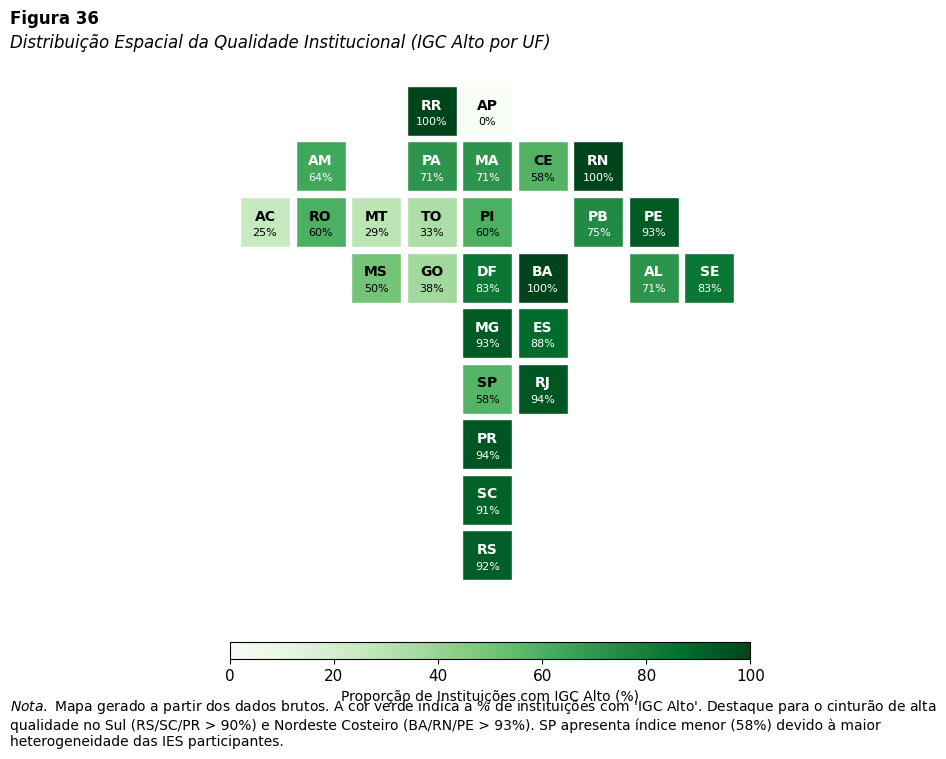

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams

# Configuração
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# Carregar Dados (Usando o arquivo que você subiu)
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    # Filtro: Apenas IES (tem_igc = 1) e com UF válida
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['uf'])

    # Cálculo da % IGC Alto por UF
    ct = pd.crosstab(df['uf'], df['igc_categoria'], normalize='index') * 100
    # Garantir que a coluna existe
    if 'IGC Alto' not in ct.columns: ct['IGC Alto'] = 0
    df_map = ct[['IGC Alto']].copy()
    df_map.columns = ['pct_alto']

except:
    # Caso o arquivo não esteja disponível no ambiente local do usuário, usar fallback ou erro
    df_map = pd.DataFrame()

# Layout do Grid (Mantido)
grid_final = {
    'RR': (0, 3), 'AP': (0, 4),
    'AM': (1, 1), 'PA': (1, 3), 'MA': (1, 4), 'CE': (1, 5), 'RN': (1, 6),
    'AC': (2, 0), 'RO': (2, 1), 'MT': (2, 2), 'TO': (2, 3), 'PI': (2, 4), 'PB': (2, 6), 'PE': (2, 7),
                  'MS': (3, 2), 'GO': (3, 3), 'DF': (3, 4), 'BA': (3, 5), 'AL': (3, 7), 'SE': (3, 8),
                                'MG': (4, 4), 'ES': (4, 5),
                                'SP': (5, 4), 'RJ': (5, 5),
                                'PR': (6, 4),
                                'SC': (7, 4),
                                'RS': (8, 4)
}

def plot_tile_map_pt():
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_aspect('equal')
    ax.axis('off')

    cmap = plt.cm.Greens
    norm = plt.Normalize(vmin=0, vmax=100)

    for uf, (row, col) in grid_final.items():
        val = df_map.loc[uf, 'pct_alto'] if uf in df_map.index else 0
        color = cmap(norm(val))

        y = -row
        rect = patches.Rectangle((col, y), 0.9, 0.9, linewidth=1, edgecolor='white', facecolor=color)
        ax.add_patch(rect)

        text_color = 'white' if val > 60 else 'black'
        ax.text(col + 0.45, y + 0.55, uf, ha='center', va='center', color=text_color, fontsize=10, weight='bold')
        ax.text(col + 0.45, y + 0.25, f"{val:.0f}%", ha='center', va='center', color=text_color, fontsize=8)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.01, aspect=30)
    cbar.set_label('Proporção de Instituições com IGC Alto (%)', fontsize=10)

    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-9, 1)

    fig.text(0.02, 0.95, "Figura 36", fontsize=12, weight='bold')
    fig.text(0.02, 0.92, "Distribuição Espacial da Qualidade Institucional (IGC Alto por UF)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Mapa gerado a partir dos dados brutos. A cor verde indica a % de instituições com 'IGC Alto'. "
            "Destaque para o cinturão de alta qualidade no Sul (RS/SC/PR > 90%) e Nordeste Costeiro (BA/RN/PE > 93%). "
            "SP apresenta índice menor (58%) devido à maior heterogeneidade das IES participantes.")
    fig.text(0.02, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig("apa_fig36_tile_map_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Tile Map Validado (PT)...")
plot_tile_map_pt()

Gerando Tile Map Validado (EN)...


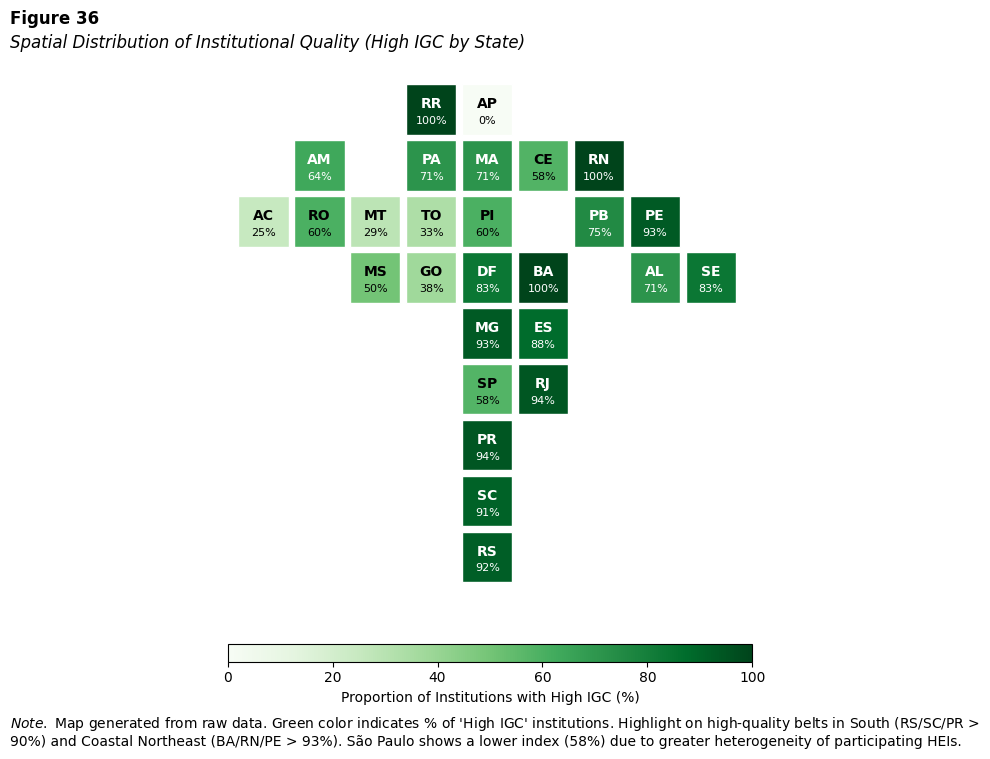

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['uf'])

    ct = pd.crosstab(df['uf'], df['igc_categoria'], normalize='index') * 100
    if 'IGC Alto' not in ct.columns: ct['IGC Alto'] = 0
    df_map = ct[['IGC Alto']].copy()
    df_map.columns = ['pct_alto']
except:
    df_map = pd.DataFrame()

grid_final = {
    'RR': (0, 3), 'AP': (0, 4),
    'AM': (1, 1), 'PA': (1, 3), 'MA': (1, 4), 'CE': (1, 5), 'RN': (1, 6),
    'AC': (2, 0), 'RO': (2, 1), 'MT': (2, 2), 'TO': (2, 3), 'PI': (2, 4), 'PB': (2, 6), 'PE': (2, 7),
                  'MS': (3, 2), 'GO': (3, 3), 'DF': (3, 4), 'BA': (3, 5), 'AL': (3, 7), 'SE': (3, 8),
                                'MG': (4, 4), 'ES': (4, 5),
                                'SP': (5, 4), 'RJ': (5, 5),
                                'PR': (6, 4),
                                'SC': (7, 4),
                                'RS': (8, 4)
}

def plot_tile_map_en():
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_aspect('equal')
    ax.axis('off')

    cmap = plt.cm.Greens
    norm = plt.Normalize(vmin=0, vmax=100)

    for uf, (row, col) in grid_final.items():
        val = df_map.loc[uf, 'pct_alto'] if uf in df_map.index else 0
        color = cmap(norm(val))
        y = -row
        rect = patches.Rectangle((col, y), 0.9, 0.9, linewidth=1, edgecolor='white', facecolor=color)
        ax.add_patch(rect)

        text_color = 'white' if val > 60 else 'black'
        ax.text(col + 0.45, y + 0.55, uf, ha='center', va='center', color=text_color, fontsize=10, weight='bold')
        ax.text(col + 0.45, y + 0.25, f"{val:.0f}%", ha='center', va='center', color=text_color, fontsize=8)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.01, aspect=30)
    cbar.set_label('Proportion of Institutions with High IGC (%)', fontsize=10)

    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-9, 1)

    fig.text(0.02, 0.95, "Figure 36", fontsize=12, weight='bold')
    fig.text(0.02, 0.92, "Spatial Distribution of Institutional Quality (High IGC by State)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Map generated from raw data. Green color indicates % of 'High IGC' institutions. "
            "Highlight on high-quality belts in South (RS/SC/PR > 90%) and Coastal Northeast (BA/RN/PE > 93%). "
            "São Paulo shows a lower index (58%) due to greater heterogeneity of participating HEIs.")
    fig.text(0.02, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig("apa_fig36_tile_map_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Tile Map Validado (EN)...")
plot_tile_map_en()

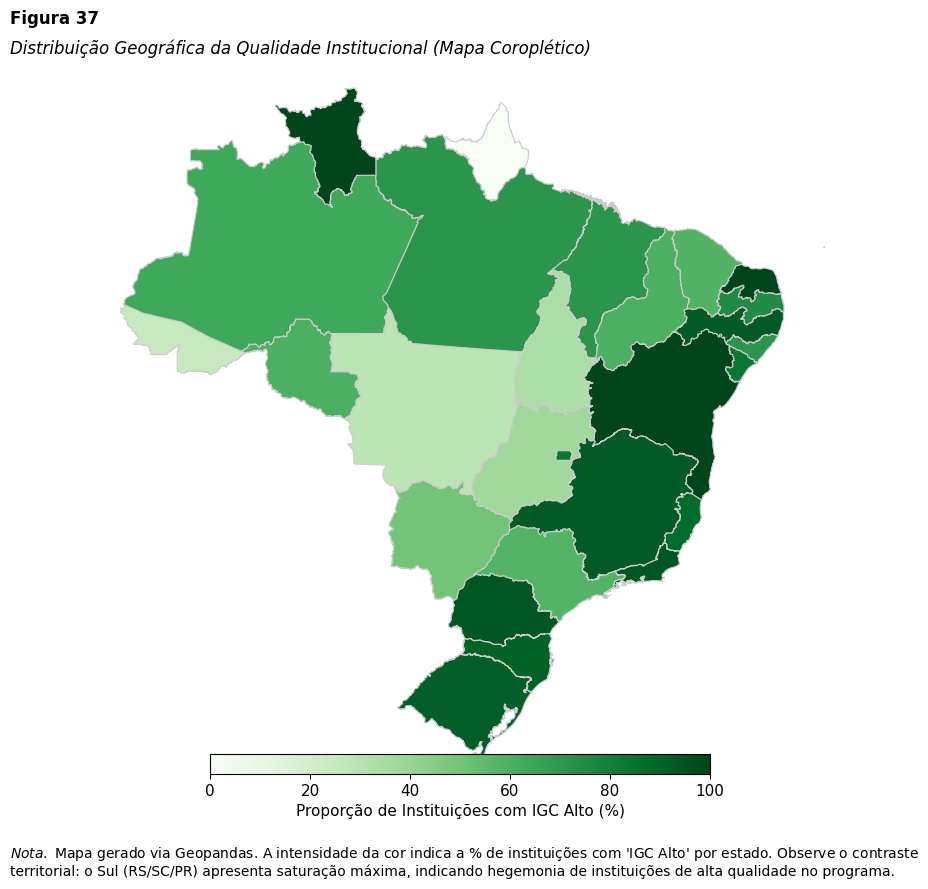

In [5]:
# ==============================================================================
# INSTRUÇÕES PARA O GOOGLE COLAB
# Instale as bibliotecas necessárias antes de rodar:
# !pip install geopandas matplotlib
# ==============================================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configuração Estética
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# 1. Carregar Dados do PIBIC-EM
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    # Filtros: Apenas IES e com UF válida
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['uf'])

    # Calcular % de IGC Alto por UF
    ct = pd.crosstab(df['uf'], df['igc_categoria'], normalize='index') * 100
    if 'IGC Alto' not in ct.columns: ct['IGC Alto'] = 0
    df_map = ct[['IGC Alto']].reset_index()
    df_map.columns = ['sigla', 'pct_alto']

except Exception as e:
    print(f"Erro ao carregar dados: {e}")
    df_map = pd.DataFrame()

# 2. Carregar Malha Geográfica (GeoJSON Online)
# Usando um repositório público estável (CodeForAmerica ou similar)
url_geojson = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

try:
    brasil = gpd.read_file(url_geojson)

    # Merge dos dados (Geometria + Dados do PIBIC)
    # O GeoJSON tem a coluna 'sigla' ou 'name'. Vamos verificar.
    # Neste dataset específico, a sigla está em 'sigla'.
    brasil = brasil.merge(df_map, left_on='sigla', right_on='sigla', how='left')
    brasil['pct_alto'] = brasil['pct_alto'].fillna(0) # Preencher vazios com 0

    # 3. Plotagem
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot do Mapa
    brasil.plot(column='pct_alto', cmap='Greens', linewidth=0.8, ax=ax, edgecolor='0.8', vmin=0, vmax=100)

    # Barra de Cores Personalizada
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar = plt.cm.ScalarMappable(norm=norm, cmap='Greens')
    ax_cbar = fig.add_axes([0.25, 0.15, 0.5, 0.02]) # [left, bottom, width, height]
    fig.colorbar(cbar, cax=ax_cbar, orientation='horizontal', label='Proporção de Instituições com IGC Alto (%)')

    # Ajustes Finais
    ax.set_axis_off() # Remover eixos lat/long

    # Títulos
    fig.text(0.05, 0.90, "Figura 37", fontsize=12, weight='bold')
    fig.text(0.05, 0.87, "Distribuição Geográfica da Qualidade Institucional (Mapa Coroplético)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Mapa gerado via Geopandas. A intensidade da cor indica a % de instituições com 'IGC Alto' por estado. "
            "Observe o contraste territorial: o Sul (RS/SC/PR) apresenta saturação máxima, indicando hegemonia de instituições de alta qualidade no programa.")
    fig.text(0.05, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.savefig("apa_fig37_choropleth_map_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Erro ao gerar mapa (verifique conexão ou biblioteca geopandas): {e}")

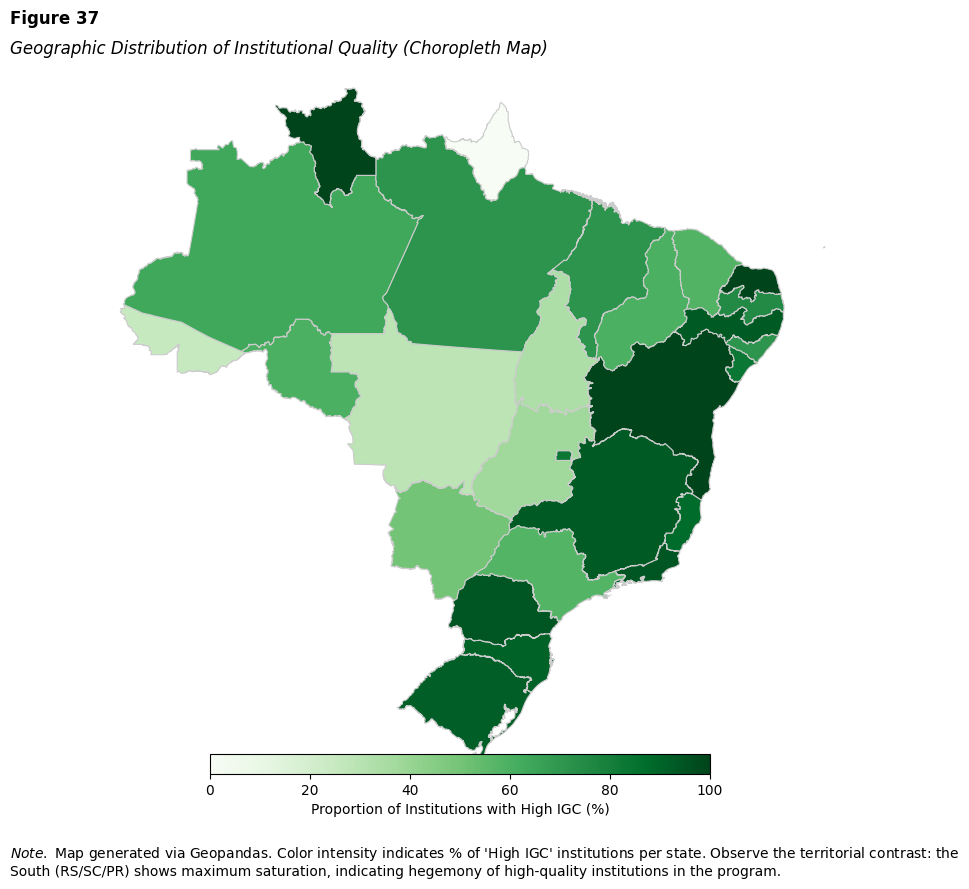

In [6]:
# ==============================================================================
# INSTRUCTIONS FOR GOOGLE COLAB
# Install required libraries first:
# !pip install geopandas matplotlib
# ==============================================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['uf'])

    ct = pd.crosstab(df['uf'], df['igc_categoria'], normalize='index') * 100
    if 'IGC Alto' not in ct.columns: ct['IGC Alto'] = 0
    df_map = ct[['IGC Alto']].reset_index()
    df_map.columns = ['sigla', 'pct_alto']

except:
    df_map = pd.DataFrame()

url_geojson = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

try:
    brasil = gpd.read_file(url_geojson)
    brasil = brasil.merge(df_map, left_on='sigla', right_on='sigla', how='left')
    brasil['pct_alto'] = brasil['pct_alto'].fillna(0)

    fig, ax = plt.subplots(figsize=(10, 10))

    brasil.plot(column='pct_alto', cmap='Greens', linewidth=0.8, ax=ax, edgecolor='0.8', vmin=0, vmax=100)

    norm = plt.Normalize(vmin=0, vmax=100)
    cbar = plt.cm.ScalarMappable(norm=norm, cmap='Greens')
    ax_cbar = fig.add_axes([0.25, 0.15, 0.5, 0.02])
    fig.colorbar(cbar, cax=ax_cbar, orientation='horizontal', label='Proportion of Institutions with High IGC (%)')

    ax.set_axis_off()

    fig.text(0.05, 0.90, "Figure 37", fontsize=12, weight='bold')
    fig.text(0.05, 0.87, "Geographic Distribution of Institutional Quality (Choropleth Map)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Map generated via Geopandas. Color intensity indicates % of 'High IGC' institutions per state. "
            "Observe the territorial contrast: the South (RS/SC/PR) shows maximum saturation, indicating hegemony of high-quality institutions in the program.")
    fig.text(0.05, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.savefig("apa_fig37_choropleth_map_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Error generating map: {e}")

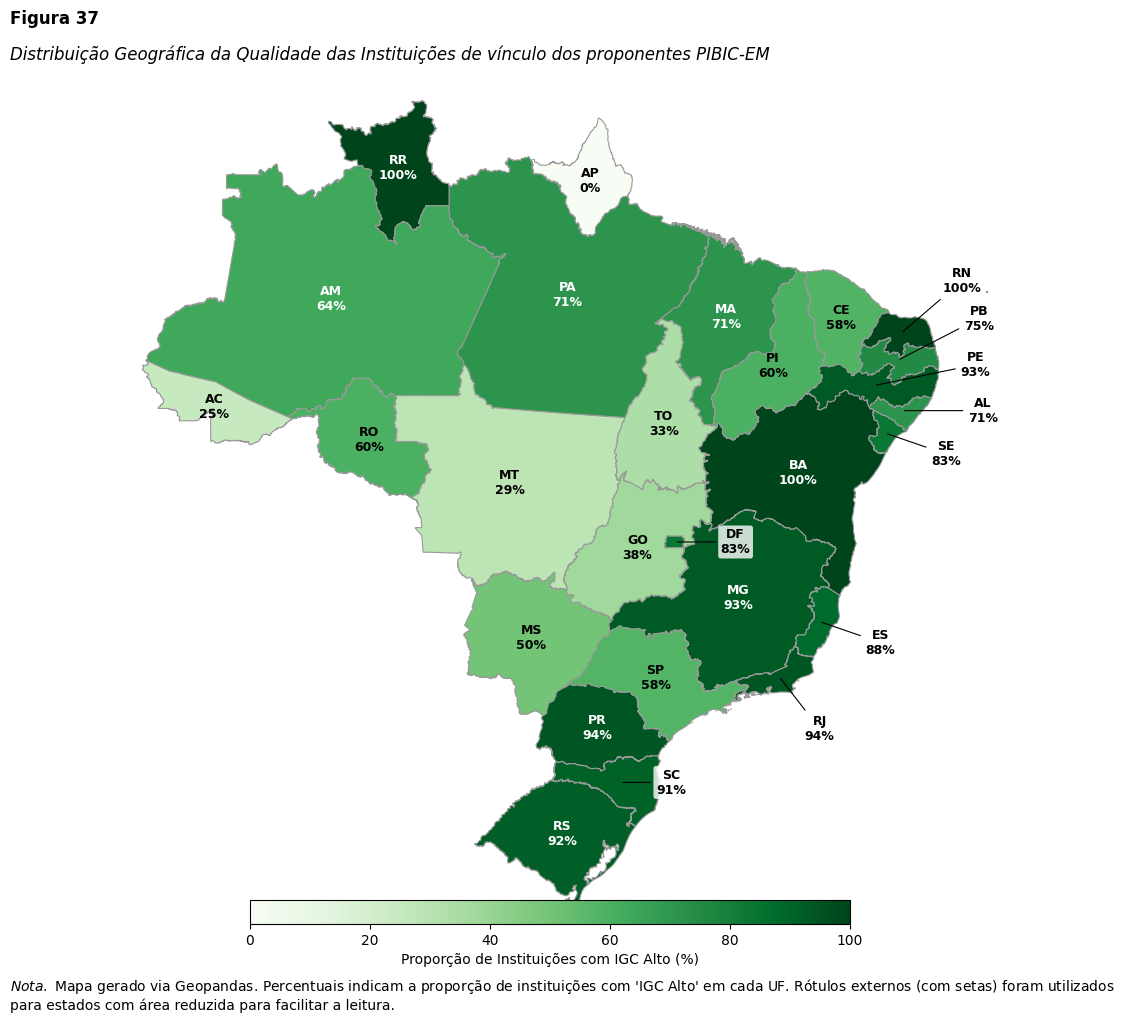

In [13]:
# ==============================================================================
# INSTRUÇÕES PARA O GOOGLE COLAB
# Instale as bibliotecas necessárias antes de rodar:
# !pip install geopandas matplotlib
# ==============================================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configuração Estética
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# 1. Carregar e Processar Dados (Do CSV)
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['uf'])

    ct = pd.crosstab(df['uf'], df['igc_categoria'], normalize='index') * 100
    if 'IGC Alto' not in ct.columns: ct['IGC Alto'] = 0
    df_map = ct[['IGC Alto']].reset_index()
    df_map.columns = ['sigla', 'pct_alto']

except Exception as e:
    print(f"Erro nos dados: {e}")
    df_map = pd.DataFrame()

# 2. Carregar Malha Geográfica
url_geojson = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

try:
    brasil = gpd.read_file(url_geojson)
    brasil = brasil.merge(df_map, left_on='sigla', right_on='sigla', how='left')
    brasil['pct_alto'] = brasil['pct_alto'].fillna(0)

    # 3. Plotagem
    fig, ax = plt.subplots(figsize=(12, 12))

    # Base do Mapa
    brasil.plot(column='pct_alto', cmap='Greens', linewidth=0.8, ax=ax, edgecolor='0.6', vmin=0, vmax=100)

    # --- LÓGICA DE ROTULAGEM AVANÇADA ---
    # Dicionário de offsets (deslocamentos) para estados pequenos (x, y)
    # Valores ajustados empiricamente para jogar os labels para o oceano
    offsets = {
        'DF': (3, 0),      # Joga para direita (dentro de MG/GO mas visível com seta)
        'SE': (3, -1),     # Oceano direita/baixo
        'AL': (4, 0),      # Oceano direita
        'PE': (5, 1),      # Oceano direita/cima
        'PB': (4, 2),      # Oceano direita/cima
        'RN': (3, 2.5),    # Oceano direita/cima
        'ES': (3, -1),     # Oceano direita
        'RJ': (2, -2.5),   # Oceano baixo
        'SC': (2.5, 0),    # Direita (Oceano)
    }

    for idx, row in brasil.iterrows():
        sigla = row['sigla']
        val = row['pct_alto']

        # Pega o centroide da geometria
        centroid = row.geometry.centroid
        x, y = centroid.x, centroid.y

        # Texto do rótulo
        label_text = f"{sigla}\n{val:.0f}%"

        # Cor do texto (Branco se fundo escuro, Preto se fundo claro)
        # Ajuste o threshold conforme necessário (60% costuma ser bom para Greens)
        text_color = 'white' if val > 60 else 'black'

        if sigla in offsets:
            # ESTADOS PEQUENOS (COM SETA)
            x_off, y_off = offsets[sigla]
            # Desenha anotação com seta
            ax.annotate(text=label_text, xy=(x, y), xytext=(x + x_off, y + y_off),
                        arrowprops=dict(arrowstyle="-", color='black', lw=0.8),
                        ha='center', va='center', fontsize=9, color='black', weight='bold',
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))
        else:
            # ESTADOS GRANDES (NO CENTRO)
            ax.text(x, y, label_text, ha='center', va='center', fontsize=9,
                    color=text_color, weight='bold')

    # Barra de Cores
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar = plt.cm.ScalarMappable(norm=norm, cmap='Greens')
    ax_cbar = fig.add_axes([0.25, 0.15, 0.5, 0.02])
    fig.colorbar(cbar, cax=ax_cbar, orientation='horizontal', label='Proporção de Instituições com IGC Alto (%)')

    ax.set_axis_off()

    # Títulos
    fig.text(0.05, 0.90, "Figura 37", fontsize=12, weight='bold')
    fig.text(0.05, 0.87, "Distribuição Geográfica da Qualidade das Instituições de vínculo dos proponentes PIBIC-EM", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Mapa gerado via Geopandas. Percentuais indicam a proporção de instituições com 'IGC Alto' em cada UF. "
            "Rótulos externos (com setas) foram utilizados para estados com área reduzida para facilitar a leitura.")
    fig.text(0.05, 0.08, note, fontsize=10, ha='left', wrap=True)

    plt.savefig("apa_fig37_choropleth_labels_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Erro ao gerar mapa: {e}")

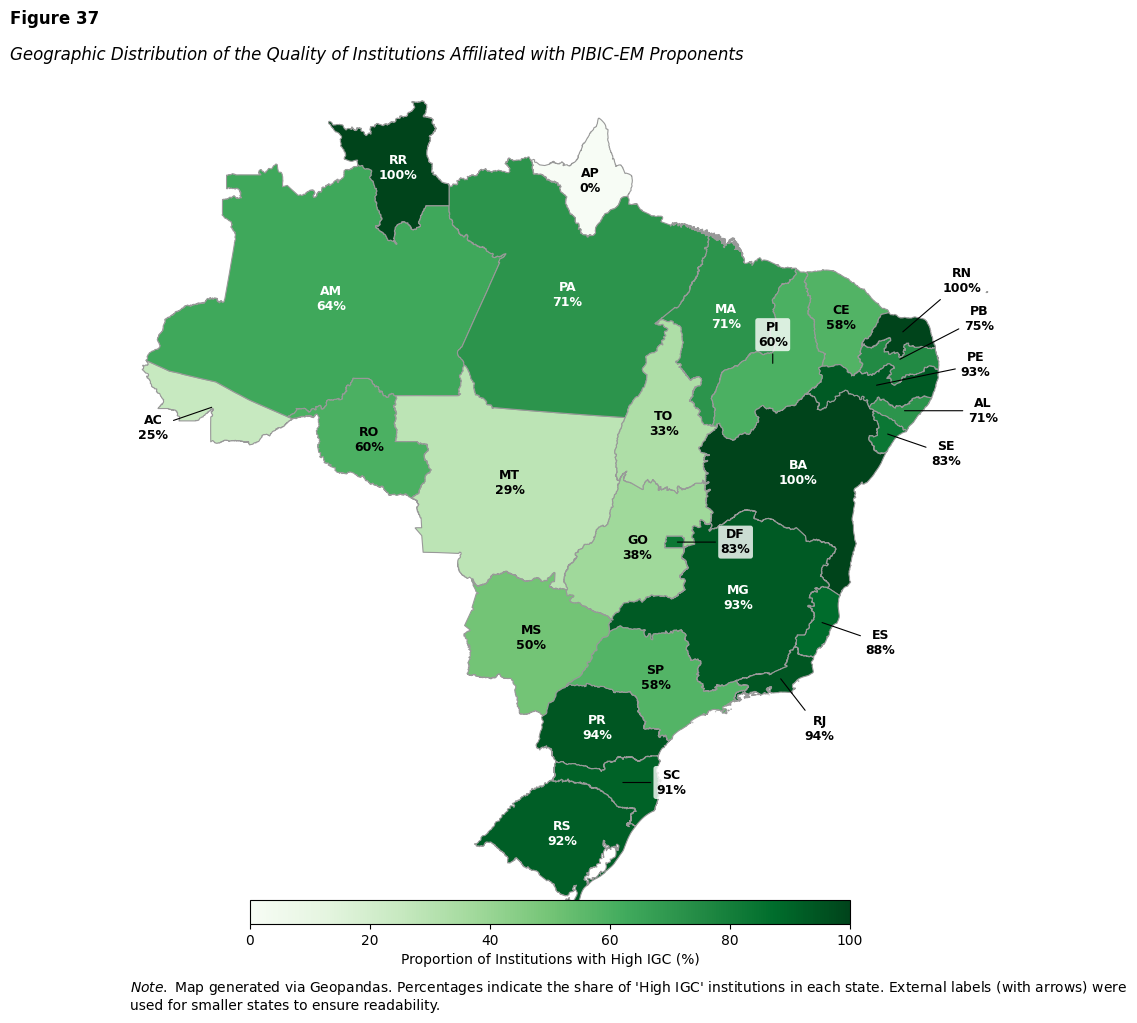

In [9]:
# ==============================================================================
# INSTRUCTIONS FOR GOOGLE COLAB
# Install required libraries first:
# !pip install geopandas matplotlib
# ==============================================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configuração Estética / Aesthetic Configuration
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# 1. Carregar e Processar Dados / Load and Process Data
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    # Filtros / Filters
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['uf'])

    # Calcular Porcentagem / Calculate Percentage
    ct = pd.crosstab(df['uf'], df['igc_categoria'], normalize='index') * 100
    if 'IGC Alto' not in ct.columns: ct['IGC Alto'] = 0
    df_map = ct[['IGC Alto']].reset_index()
    df_map.columns = ['sigla', 'pct_alto']

except Exception as e:
    print(f"Error processing data: {e}")
    df_map = pd.DataFrame()

# 2. Carregar Malha Geográfica / Load Geographic Shapes
url_geojson = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

try:
    brasil = gpd.read_file(url_geojson)
    brasil = brasil.merge(df_map, left_on='sigla', right_on='sigla', how='left')
    brasil['pct_alto'] = brasil['pct_alto'].fillna(0)

    # 3. Plotagem / Plotting
    fig, ax = plt.subplots(figsize=(12, 12))

    # Base do Mapa / Map Base
    brasil.plot(column='pct_alto', cmap='Greens', linewidth=0.8, ax=ax, edgecolor='0.6', vmin=0, vmax=100)

    # --- LÓGICA DE ROTULAGEM (LABELS & ARROWS) ---
    # Offsets para estados pequenos (x, y) / Offsets for small states
    offsets = {
        'DF': (3, 0),      # Right
        'SE': (3, -1),     # Right/Down
        'AL': (4, 0),      # Right
        'PE': (5, 1),      # Right/Up
        'PB': (4, 2),      # Right/Up
        'RN': (3, 2.5),    # Right/Up
        'ES': (3, -1),     # Right
        'RJ': (2, -2.5),   # Down
        'SC': (2.5, 0),    # Right
        'PI': (0, 1.5),    # Up
        'AC': (-3, -1)     # Left
    }

    for idx, row in brasil.iterrows():
        sigla = row['sigla']
        val = row['pct_alto']

        centroid = row.geometry.centroid
        x, y = centroid.x, centroid.y

        label_text = f"{sigla}\n{val:.0f}%"

        # Text color contrast
        text_color = 'white' if val > 60 else 'black'

        if sigla in offsets:
            # Arrows for small states
            x_off, y_off = offsets[sigla]
            ax.annotate(text=label_text, xy=(x, y), xytext=(x + x_off, y + y_off),
                        arrowprops=dict(arrowstyle="-", color='black', lw=0.8),
                        ha='center', va='center', fontsize=9, color='black', weight='bold',
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))
        else:
            # Labels for large states
            ax.text(x, y, label_text, ha='center', va='center', fontsize=9,
                    color=text_color, weight='bold')

    # Colorbar
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar = plt.cm.ScalarMappable(norm=norm, cmap='Greens')
    ax_cbar = fig.add_axes([0.25, 0.15, 0.5, 0.02])
    fig.colorbar(cbar, cax=ax_cbar, orientation='horizontal', label='Proportion of Institutions with High IGC (%)')

    ax.set_axis_off()

    # Titles and Notes (English)
    fig.text(0.05, 0.90, "Figure 37", fontsize=12, weight='bold')
    fig.text(0.05, 0.87, "Geographic Distribution of the Quality of Institutions Affiliated with PIBIC-EM Proponents", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Map generated via Geopandas. Percentages indicate the share of 'High IGC' institutions in each state. "
            "External labels (with arrows) were used for smaller states to ensure readability.")
    fig.text(0.15, 0.08, note, fontsize=10, ha='left', wrap=True)

    plt.savefig("apa_fig37_choropleth_labels_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Error generating map: {e}")

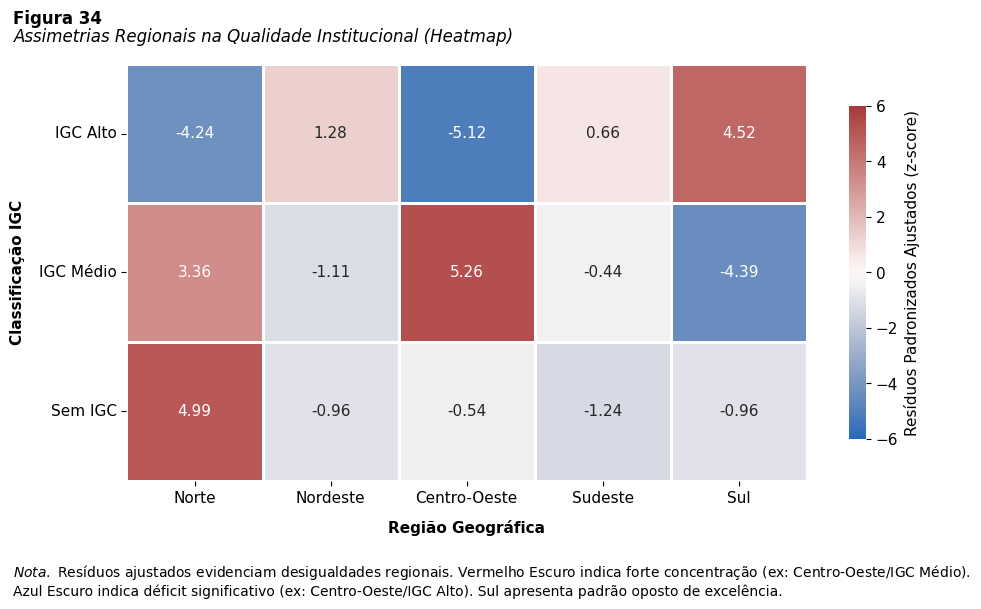

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# Configuração Estética APA 7
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# Carregar Dados
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    # Filtros
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['regiao_corrigida'])

except Exception as e:
    df = pd.DataFrame()

# Função de Resíduos Ajustados (Haberman)
def get_adj_residuals(data, col_x, col_y):
    ct = pd.crosstab(data[col_y], data[col_x])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)

    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        adj_res = (observed - expected) / div

    return pd.DataFrame(adj_res, index=ct.index, columns=ct.columns).fillna(0)

def plot_heatmap_regional_pt():
    residuos = get_adj_residuals(df, 'regiao_corrigida', 'igc_categoria')

    # Ordenação
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ordem_reg = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
    residuos = residuos.reindex(index=ordem_igc, columns=ordem_reg)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Heatmap com escala divergente e fixa (-6 a +6)
    sns.heatmap(residuos, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-6, vmax=6,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Resíduos Padronizados Ajustados (z-score)', 'shrink': 0.8}, ax=ax)

    ax.set_xlabel("Região Geográfica", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Classificação IGC", weight='bold', fontsize=11, labelpad=10)
    plt.yticks(rotation=0)

    fig.text(0.02, 0.96, "Figura 34", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Assimetrias Regionais na Qualidade Institucional (Heatmap)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Resíduos ajustados evidenciam desigualdades regionais. "
            "Vermelho Escuro indica forte concentração (ex: Centro-Oeste/IGC Médio). "
            "Azul Escuro indica déficit significativo (ex: Centro-Oeste/IGC Alto). "
            "Sul apresenta padrão oposto de excelência.")
    fig.text(0.02, 0.01, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig34_heatmap_regional_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_heatmap_regional_pt()

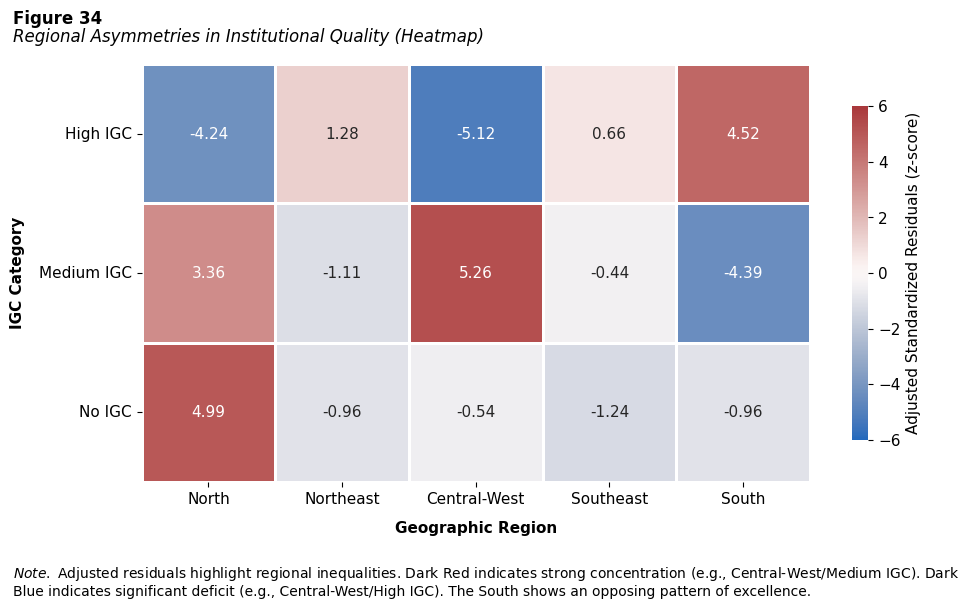

In [12]:
def plot_heatmap_regional_en():
    # Mappings
    mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}
    mapa_reg_en = {
        'Norte': 'North', 'Nordeste': 'Northeast', 'Centro-Oeste': 'Central-West',
        'Sudeste': 'Southeast', 'Sul': 'South'
    }
    df['igc_en'] = df['igc_categoria'].map(mapa_igc_en)
    df['reg_en'] = df['regiao_corrigida'].map(mapa_reg_en)

    residuos = get_adj_residuals(df, 'reg_en', 'igc_en')

    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']
    ordem_reg = ['North', 'Northeast', 'Central-West', 'Southeast', 'South']
    residuos = residuos.reindex(index=ordem_igc, columns=ordem_reg)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(residuos, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-6, vmax=6,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Adjusted Standardized Residuals (z-score)', 'shrink': 0.8}, ax=ax)

    ax.set_xlabel("Geographic Region", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("IGC Category", weight='bold', fontsize=11, labelpad=10)
    plt.yticks(rotation=0)

    fig.text(0.02, 0.96, "Figure 34", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Regional Asymmetries in Institutional Quality (Heatmap)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Adjusted residuals highlight regional inequalities. "
            "Dark Red indicates strong concentration (e.g., Central-West/Medium IGC). "
            "Dark Blue indicates significant deficit (e.g., Central-West/High IGC). "
            "The South shows an opposing pattern of excellence.")
    fig.text(0.02, 0.01, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig34_heatmap_regional_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_heatmap_regional_en()

Gerando Barras Empilhadas Regionais (PT)...


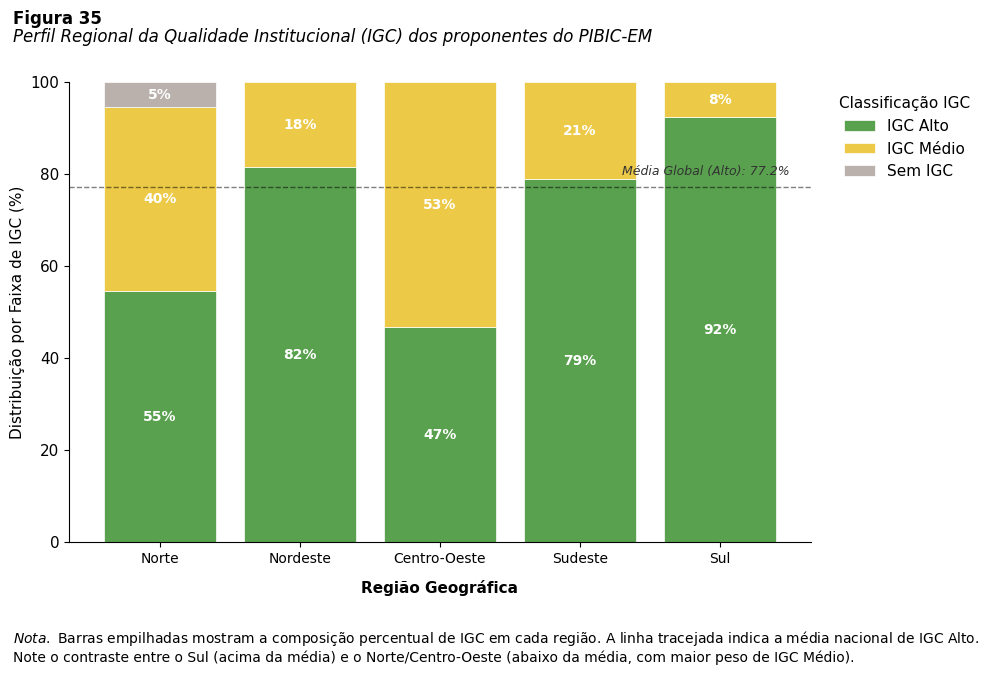

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)

    # Filtro: Apenas IES (tem_igc = 1)
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['regiao_corrigida'])
except:
    df = pd.DataFrame()

# ==============================================================================
# PLOTAGEM (PT)
# ==============================================================================
def plot_stacked_regional_final_pt():
    # Crosstab normalizado (100% por Região)
    ct = pd.crosstab(df['regiao_corrigida'], df['igc_categoria'], normalize='index') * 100

    # Ordem das Colunas (IGC) - Alto na base para facilitar comparação
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])

    # Ordem das Linhas (Geográfica: Norte -> Sul)
    ordem_reg = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
    ct = ct.reindex(ordem_reg)

    # Média Global (Linha de Referência)
    media_global_alto = (df['igc_categoria'] == 'IGC Alto').mean() * 100

    fig, ax = plt.subplots(figsize=(10, 6))

    # Cores
    colors = {
        'IGC Alto': '#59a14f',   # Verde (Excelência)
        'IGC Médio': '#edc948',  # Amarelo (Médio)
        'Sem IGC': '#bab0ac'     # Cinza (Residual)
    }
    color_list = [colors.get(c, '#bab0ac') for c in ct.columns]

    # Plot
    ct.plot(kind='bar', stacked=True, width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # Linha de Referência
    ax.axhline(media_global_alto, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(len(ct)-0.5, media_global_alto + 2, f'Média Global (Alto): {media_global_alto:.1f}%',
            va='bottom', ha='right', fontsize=9, style='italic', color='#333')

    # Rótulos
    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')

    ax.set_xlabel("Região Geográfica", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Distribuição por Faixa de IGC (%)", fontsize=11)
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0, ha='center', fontsize=10)

    # Legenda Externa
    ax.legend(title="Classificação IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # Títulos e Nota
    fig.text(0.02, 0.98, "Figura 35", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Perfil Regional da Qualidade Institucional (IGC) dos proponentes do PIBIC-EM", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Barras empilhadas mostram a composição percentual de IGC em cada região. "
            "A linha tracejada indica a média nacional de IGC Alto. Note o contraste entre o Sul (acima da média) "
            "e o Norte/Centro-Oeste (abaixo da média, com maior peso de IGC Médio).")
    fig.text(0.02, -0.08, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig35_stacked_regional_final_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Barras Empilhadas Regionais (PT)...")
plot_stacked_regional_final_pt()

Gerando Barras Empilhadas Regionais (EN)...


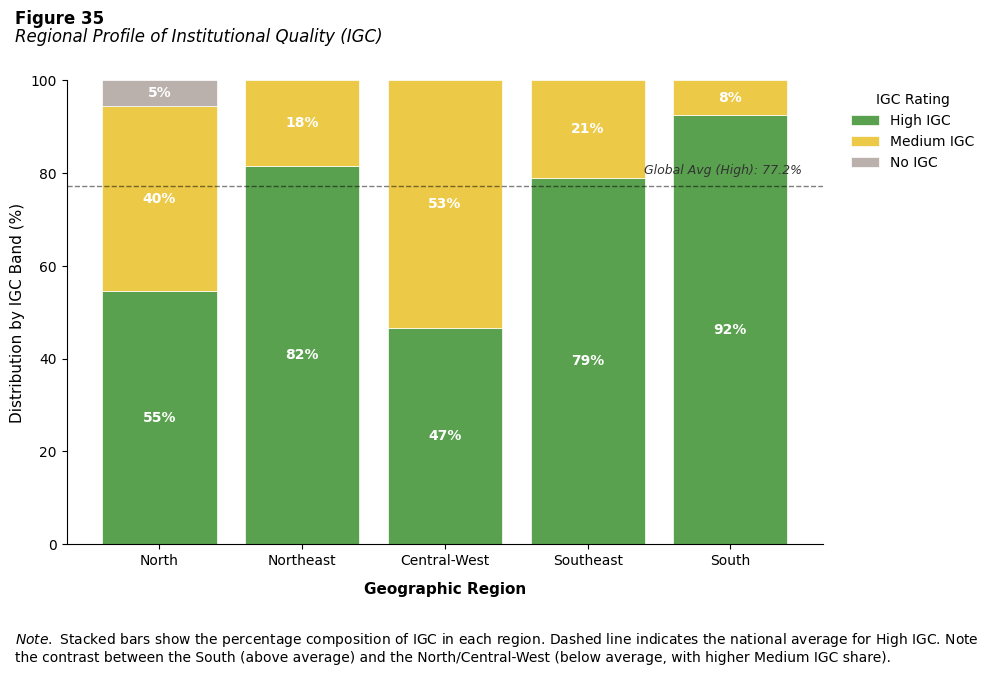

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['regiao_corrigida'])
except:
    df = pd.DataFrame()

# Mapeamentos EN
mapa_reg_en = {'Norte': 'North', 'Nordeste': 'Northeast', 'Centro-Oeste': 'Central-West',
               'Sudeste': 'Southeast', 'Sul': 'South'}
mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}

df['reg_en'] = df['regiao_corrigida'].map(mapa_reg_en)
df['igc_en'] = df['igc_categoria'].map(mapa_igc_en)

def plot_stacked_regional_final_en():
    ct = pd.crosstab(df['reg_en'], df['igc_en'], normalize='index') * 100

    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']
    ct = ct.reindex(columns=ordem_igc)
    ordem_reg = ['North', 'Northeast', 'Central-West', 'Southeast', 'South']
    ct = ct.reindex(ordem_reg)

    global_high = (df['igc_en'] == 'High IGC').mean() * 100

    fig, ax = plt.subplots(figsize=(10, 6))

    colors_en = {'High IGC': '#59a14f', 'Medium IGC': '#edc948', 'No IGC': '#bab0ac'}
    color_list = [colors_en.get(c) for c in ct.columns]

    ct.plot(kind='bar', stacked=True, width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    ax.axhline(global_high, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(len(ct)-0.5, global_high + 2, f'Global Avg (High): {global_high:.1f}%',
            va='bottom', ha='right', fontsize=9, style='italic', color='#333')

    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')

    ax.set_xlabel("Geographic Region", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Distribution by IGC Band (%)", fontsize=11)
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0, ha='center', fontsize=10)

    ax.legend(title="IGC Rating", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.98, "Figure 35", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Regional Profile of Institutional Quality (IGC)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Stacked bars show the percentage composition of IGC in each region. "
            "Dashed line indicates the national average for High IGC. Note the contrast between the South (above average) "
            "and the North/Central-West (below average, with higher Medium IGC share).")
    fig.text(0.02, -0.08, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig35_stacked_regional_final_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Barras Empilhadas Regionais (EN)...")
plot_stacked_regional_final_en()